# RCDS Optimization applied to `CAXSim`

`2026/08/27 14:10`

First I need to import `apsuite` into the `base` conda environment.

In [1]:
import os
import sys

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))
# sys.path.append(os.path.expanduser("~/repos/cax-control"))
# sys.path.append(os.path.expanduser("~/repos/apsuite"))
# sys.path.append(os.path.expanduser("~/repos/mathphys"))

import matplotlib.pyplot as plt

# from Shadow import histo
import numpy as np
from shadowpy.cax_simulation import CAXSim
from shadowpy.utils import save_image


No module named 'xraylib'


In [2]:
from apsuite.optimization.rcds import RCDSParams, RCDS

In [3]:
cax = CAXSim()


 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Ca

/home/gabriel.amici/repos/cax-scripts/caxscripts/image_statistics.py:121: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()
/home/gabriel.amici/repos/cax-control/shadowpy/shadowpy/utils.py:197: UserWarning: Beam not visible; skipping momenta analysis.
  ana.compute_momenta(useroi=False)


Traced through element 2: DVF_A1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 3: DVF_B1


(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': '2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

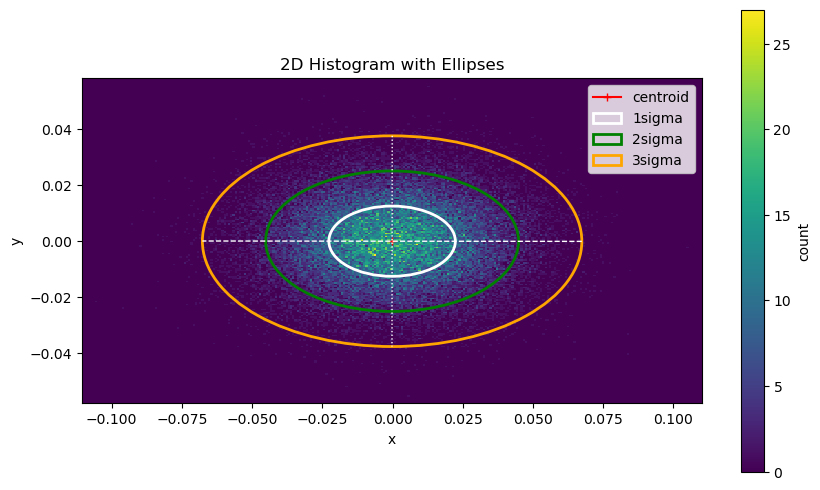

In [4]:
cax.dvf_B1.image.plot()

## 1. Simple objective function

Using the following objective function:

$$
    f_1(\sigma_x, \sigma_y, I) = \frac{\sigma_x \sigma_y}{I}
$$

The minimization of $f_1$ implies a maximization of intensity while the spactial
dimensions decrease. We'll also start by optimizing only 2 axes of motion, let's
pick TX and RY:

In [ ]:
def obj_func_intensity(cax: CAXSim):

    img_obj = cax.dvf_B1.image

    intensity = np.sum(img_obj.img)

    img_obj.fit(useroi=True)

    if img_obj.hprm_fitting is None:
        return np.nan
    sig_x = img_obj.hprm_fitting['sig_major'] * 1.e3 #[μm]
    sig_y = img_obj.hprm_fitting['sig_minor'] * 1.e3 #[μm]

    return sig_x*sig_y/intensity

In [ ]:
class CAXOptParams(RCDSParams):

    def __init__(self):
        super().__init__()

class CAXOpt(RCDS):

    def __init__(self, isonline=True, use_thread=True):
        super().__init__(isonline=isonline, use_thread=use_thread)
        self.params = CAXOptParams()    

    def objective_function(self, pos):
        cax = self.params.caxsim

        tx, ry, z_pos = pos

        cax.mirror.tx = tx
        cax.mirror.ry = ry
        cax.dvf_B1.tz = z_pos

        return obj_func_intensity(cax)

In [ ]:
caxopt = CAXOpt(use_thread=False)

In [ ]:
# problem-specific params

# motor limits: TX and RY
caxopt.params.limit_lower = [-4., -0.1, -150] # -4 mm and -0.1 mrad and -15cm
caxopt.params.limit_upper = [4., 0.1, 150] # 4 mm and 0.1 mrad and 15cm
# if the workflow of the objective function evaluations
# or other routines in the main optimzation class depend
# on additional parameters, they could be set here as well
caxopt.params.caxsim = cax
# RCDS params
# these are the parameters RCDS requires for its internal
# logic and operations
caxopt.params.max_number_evals = 500
caxopt.params.max_number_iters = 5
caxopt.params.initial_stepsize = 0.001
caxopt.params.noise_level = 1e-4
caxopt.params.tolerance = 1e-9

# initial position refers to the initial point in the
# optimaztion variables space
# you could set it to a particular value or sample
# the available search space ramdomly, as below
caxopt.params.initial_position = np.random.uniform(
    low=caxopt.params.limit_lower, high=caxopt.params.limit_upper)

# search directions along whith to start the line
# minimizations. It is a matrix with each row standing for a
# given direction

# initial directions are purely TX and RY
caxopt.params.initial_search_directions = np.eye(3)

print(caxopt.params)

In [5]:
import logging

root = logging.getLogger()
root.setLevel(logging.INFO)
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)
root.addHandler(handler)

In [ ]:
caxopt.start()

In [ ]:
caxopt.plot_history()

In [ ]:
caxopt.plot_knobspace_slice()

In [ ]:
tx, ry, z_pos = caxopt.positions_best[-1]
tx_i, ry_i, z_pos_i = caxopt.positions_best[0]

tx, ry, z_pos

In [ ]:
tx_i, ry_i, z_pos_i

In [ ]:
cax = CAXSim(total_rays=500000)

cax.mirror.tx = tx_i
cax.mirror.ry = ry_i
cax.dvf_B1.tz = z_pos_i

cax.dvf_B1.image.plot()

print(f"Before optimization: sig_x = {cax.dvf_B1.image.hprm_fitting['sig_major']*1e3:.3f} \n"
      f"Before optimization: sig_y = {cax.dvf_B1.image.hprm_fitting['sig_minor']*1e3:.3f}")

cax.mirror.tx = tx
cax.mirror.ry = ry
cax.dvf_B1.tz = z_pos

print(f"After optimization: sig_x = {cax.dvf_B1.image.hprm_fitting['sig_major']*1e3:.3f} \n"
      f"After optimization: sig_y = {cax.dvf_B1.image.hprm_fitting['sig_minor']*1e3:.3f}")

cax.dvf_B1.image.plot()

In [30]:
def _astigmatism_acquisition(cax: CAXSim):

    # Initial search

    low_lim = -1000
    hgh_lim =  1000

    done = False

    while not done:
        distances, fwhm_x, fwhm_y = \
            cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam.duplicate(),
                                        s_range=(low_lim, hgh_lim),
                                        n_points=50, 
                                        max_workers=10)
        # prior focal lengths
        fx = distances[np.nanargmin(fwhm_x)]
        fy = distances[np.nanargmin(fwhm_y)]

        print(fx, fy)

        done = True

        # check if the search was enought otherwise repeat
        if low_lim in [fx, fy]:
            low_lim -= 100
            done = False

        if hgh_lim in [fx, fy]:
            hgh_lim += 100
            done = False

    # Finer search
    distances, fwhm_x, fwhm_y = \
    cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam.duplicate(),
                                s_range=(np.min([fx, fy])-50, np.max([fx, fy])+50),
                                n_points=100, 
                                max_workers=10)

    # actual focal lengths
    fx = distances[np.nanargmin(fwhm_x)]
    fy = distances[np.nanargmin(fwhm_y)]
    print(fx, fy)

    f = np.mean([fx, fy])
    retr_beam = cax.dvf_B1.beam.duplicate()
    retr_beam.retrace(f)
    ana = save_image(cax.dvf_B1, retr_beam)
    astig = fy - fx

    return distances, fwhm_x, fwhm_y, fx, fy, f, astig, ana 


Calculating caustic in parallel...
Caustic calculation completed.
-795.9183673469388 591.8367346938776
Calculating caustic in parallel...
Caustic calculation completed.
-800.834879406308 581.7254174397033


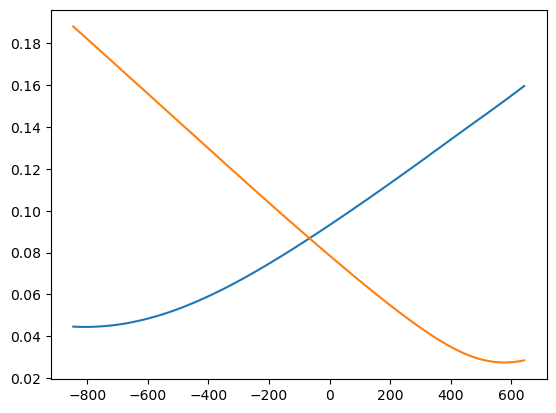

In [31]:
distances, fwhm_x, fwhm_y, fx, fy, f, astig, ana = _astigmatism_acquisition(cax)

plt.plot(distances, fwhm_x)
plt.plot(distances, fwhm_y)

In [42]:
def obj_func_astigmatism(cax):

    distances, fwhm_x, fwhm_y, fx, fy, f, astig, ana = _astigmatism_acquisition(cax)

    return np.abs(astig) + np.abs(f)

In [43]:
params = RCDSParams()

# problem-specific params

# motor limits: TX and RY
params.limit_lower = [-4., -0.2] # -4 mm and -0.1 mrad and -15cm
params.limit_upper = [4., 0.2] # 4 mm and 0.1 mrad and 15cm
params.caxsim = CAXSim()
# RCDS params
# these are the parameters RCDS requires for its internal
# logic and operations
params.max_number_evals = 500
params.max_number_iters = 5
params.initial_stepsize = 0.001
params.noise_level = 1e-4
params.tolerance = 1e-9

# initial position refers to the initial point in the
# optimaztion variables space
# you could set it to a particular value or sample
# the available search space ramdomly, as below
params.initial_position = np.random.uniform(
    low=params.limit_lower, high=params.limit_upper)

# search directions along whith to start the line
# minimizations. It is a matrix with each row standing for a
# given direction

# initial directions are purely TX and RY
params.initial_search_directions = np.eye(2)

print(params)

 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE
Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Ca

/home/gabriel.amici/repos/cax-scripts/caxscripts/image_statistics.py:121: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()
/home/gabriel.amici/repos/cax-control/shadowpy/shadowpy/utils.py:197: UserWarning: Beam not visible; skipping momenta analysis.
  ana.compute_momenta(useroi=False)


 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 3: DVF_B1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
initial_stepsize              :      0.001 
noise_level                   :      0.000 
tolerance                     :      0.000 
orthogonality_threshold       :      0.900 
update_search_directions      : True       
linescan_num_pts              :          6 
linescan_min_pts_fit          :          4 
outlier_method                : Xiaobiao   
outlier_max_err_factor        :      3.000 
outlier_percentile_limit      :      0.250 
max_number_iters              :          5 
max_number_evals              :        500 
boundary_policy               : ToNaN      

Positions          

In [44]:
class AstigOpt(RCDS):

    def __init__(self, use_thread=True, isonline=True):
        super().__init__(use_thread=use_thread, isonline=isonline)
        self.params = params

    def objective_function(self, pos):

        tx, ry = pos
        caxsim = self.params.caxsim

        caxsim.mirror.tx = tx
        caxsim.mirror.ry = ry

        caxsim.trace()

        return obj_func_astigmatism(caxsim)

In [45]:
astig_opt = AstigOpt(False, True)

In [46]:
astig_opt.start()

 Call to RESET
 Exit from RESET
Traced through element 1: M1
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 2: DVF_A1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 3: DVF_B1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR


/home/gabriel.amici/repos/apsuite/apsuite/optimization/rcds.py:542: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 1000x1000 with 2 Axes>,
 array([<Axes: xlabel='evaluations', ylabel='objective function'>,
        <Axes: xlabel='evaluations', ylabel='knobs values'>], dtype=object))

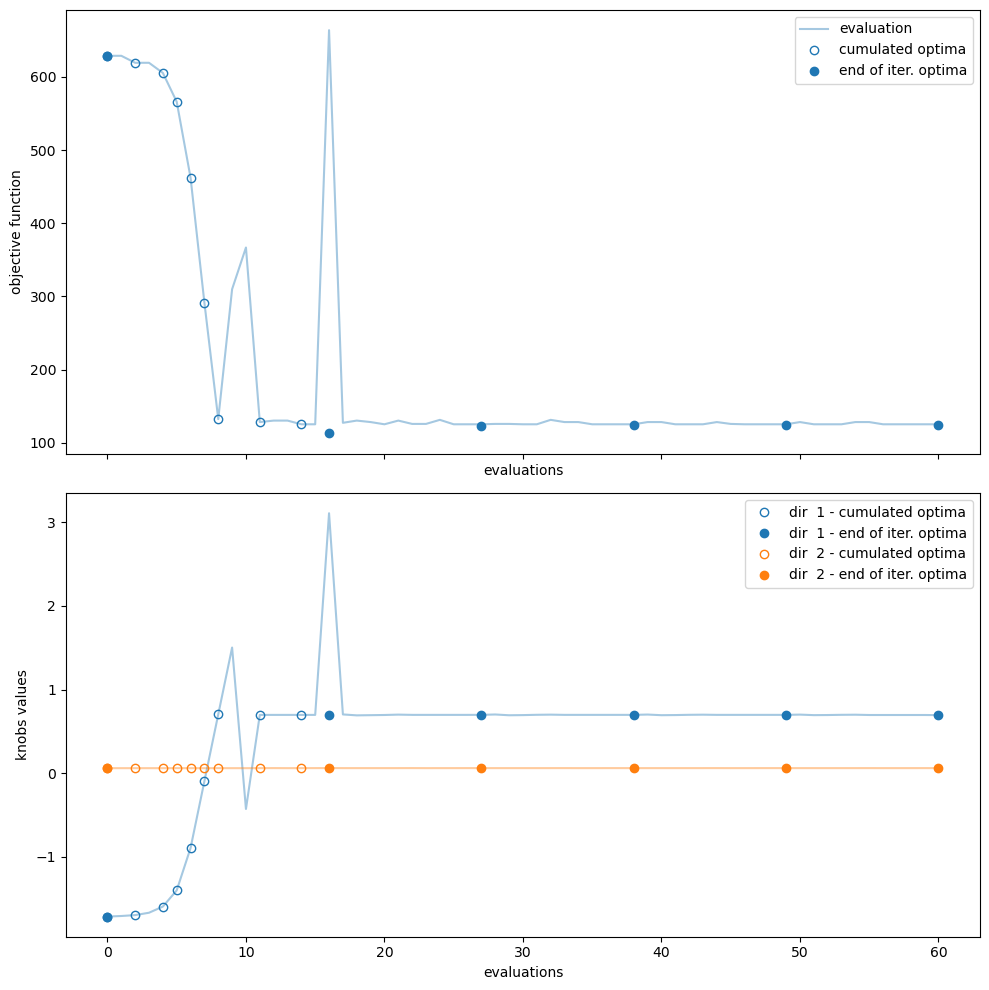

In [47]:
astig_opt.plot_history()

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'parameter space slice'}, xlabel='dir 1', ylabel='dir 2'>)

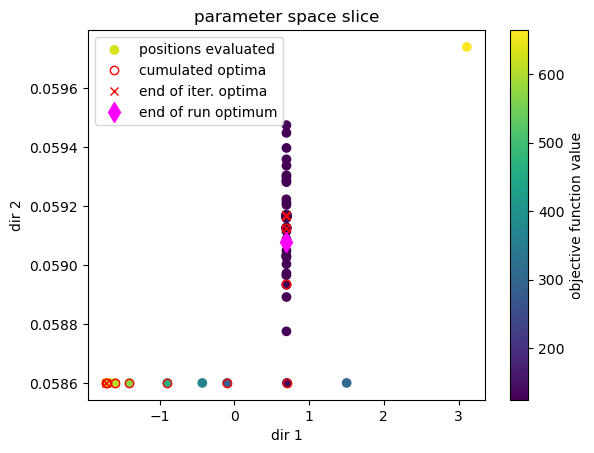

In [48]:
astig_opt.plot_knobspace_slice()

 Generated        25000  rays out of       500000
                  50000
                  75000
                 100000
                 125000
                 150000
                 175000
                 200000
                 225000
                 250000
                 275000
                 300000
                 325000
                 350000
                 375000
                 400000
                 425000
                 450000
                 475000
                 500000
 Exit from SOURCE
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
Traced through element 1: M1
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Ca

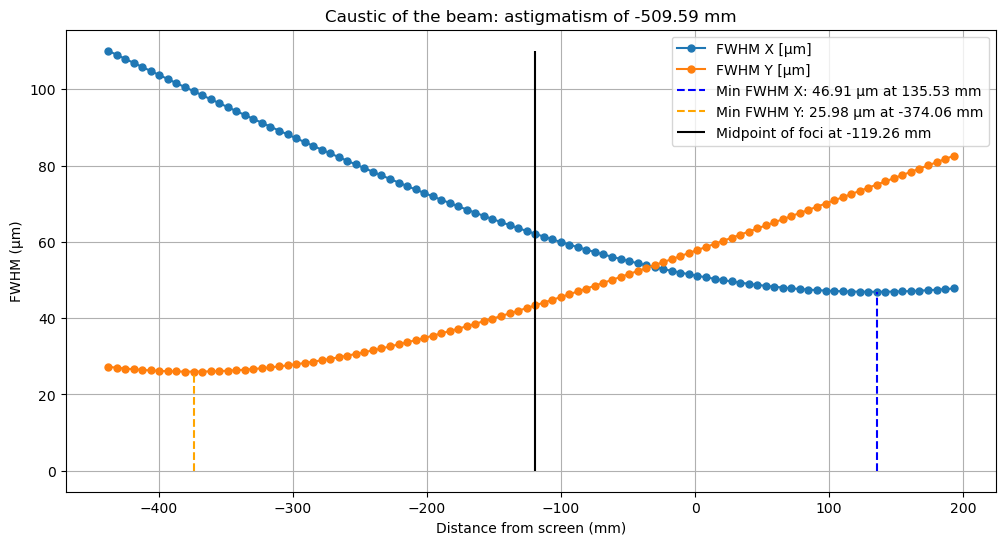

In [49]:
tx_i, ry_i = astig_opt.params.initial_position

cax = CAXSim(total_rays=500000)

cax.mirror.tx = tx_i
cax.mirror.ry = ry_i
cax.trace()

distances, fwhm_x, fwhm_y, fx, fy, f, astig, ana = _astigmatism_acquisition(cax)

plt.figure(figsize=(12, 6))
plt.plot(distances, 1000*fwhm_x, marker='o', markersize=5, label="FWHM X [μm]")
plt.plot(distances, 1000*fwhm_y, marker='o', markersize=5, label="FWHM Y [μm]")
plt.vlines(fx, 0, 1000*np.nanmin(fwhm_x), color='blue', linestyle='--', label=f"Min FWHM X: {1000*np.nanmin(fwhm_x):.2f} μm at {distances[np.nanargmin(fwhm_x)]:.2f} mm")
plt.vlines(fy, 0, 1000*np.nanmin(fwhm_y), color='orange', linestyle='--', label=f"Min FWHM Y: {1000*np.nanmin(fwhm_y):.2f} μm at {distances[np.nanargmin(fwhm_y)]:.2f} mm")
plt.vlines(f, 0, 1000*np.nanmax(fwhm_x), color='black', linestyle='solid', label=f"Midpoint of foci at {f:.2f} mm")
plt.xlabel('Distance from screen (mm)')
plt.ylabel('FWHM (μm)')
plt.title(f'Caustic of the beam: astigmatism of {astig:.2f} mm')
plt.legend()
plt.grid()
plt.show()

 Generated        25000  rays out of       500000
                  50000
                  75000
                 100000
                 125000
                 150000
                 175000
                 200000
                 225000
                 250000
                 275000
                 300000
                 325000
                 350000
                 375000
                 400000
                 425000
                 450000
                 475000
                 500000
 Exit from SOURCE
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
Traced through element 1: M1
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


/home/gabriel.amici/repos/cax-scripts/caxscripts/image_statistics.py:121: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()
/home/gabriel.amici/repos/cax-control/shadowpy/shadowpy/utils.py:197: UserWarning: Beam not visible; skipping momenta analysis.
  ana.compute_momenta(useroi=False)


 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
Traced through element 2: DVF_A1
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 3: DVF_B1
Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Ex

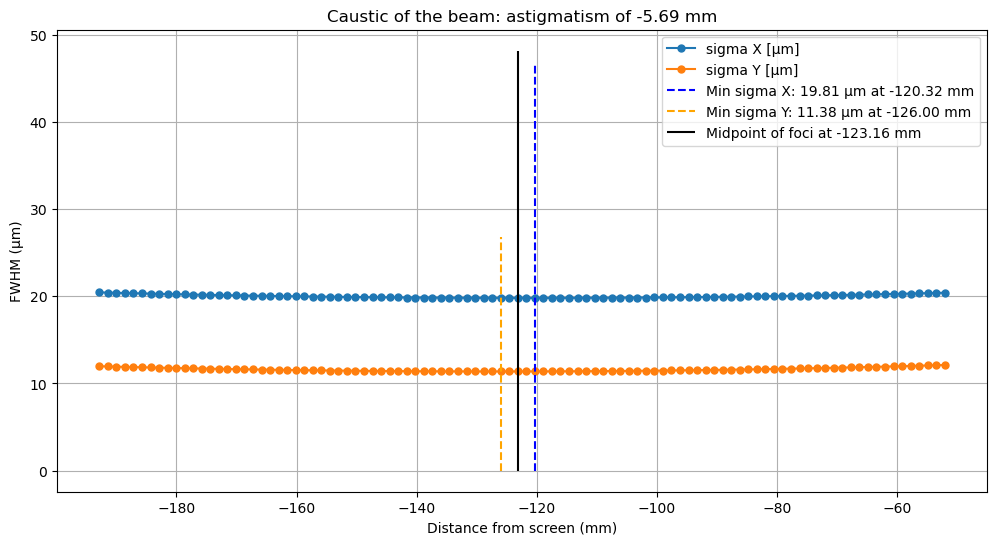

In [52]:
tx, ry = astig_opt.positions_best[-1]

cax = CAXSim(total_rays=500000)

cax.mirror.tx = tx
cax.mirror.ry = ry
cax.trace()

distances, fwhm_x, fwhm_y, fx, fy, f, astig, ana = _astigmatism_acquisition(cax)

plt.figure(figsize=(12, 6))
plt.plot(distances, 1000*fwhm_x/2.355, marker='o', markersize=5, label="sigma X [μm]")
plt.plot(distances, 1000*fwhm_y/2.355, marker='o', markersize=5, label="sigma Y [μm]")
plt.vlines(fx, 0, 1000*np.nanmin(fwhm_x), color='blue', linestyle='--', label=f"Min sigma X: {1000*np.nanmin(fwhm_x)/2.355:.2f} μm at {distances[np.nanargmin(fwhm_x)]:.2f} mm")
plt.vlines(fy, 0, 1000*np.nanmin(fwhm_y), color='orange', linestyle='--', label=f"Min sigma Y: {1000*np.nanmin(fwhm_y)/2.355:.2f} μm at {distances[np.nanargmin(fwhm_y)]:.2f} mm")
plt.vlines(f, 0, 1000*np.nanmax(fwhm_x), color='black', linestyle='solid', label=f"Midpoint of foci at {f:.2f} mm")
plt.xlabel('Distance from screen (mm)')
plt.ylabel('FWHM (μm)')
plt.title(f'Caustic of the beam: astigmatism of {astig:.2f} mm')
plt.legend()
plt.grid()
plt.show()

In [51]:
tx, ry

(0.6949769855352974, 0.05908011468073776)